Data preprocessing (Z-score standardization) and PCA with eigenvalue decomposition (whitening) built from scratch.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Load Complex Geospatial Dataset (Aligns with "spatial datasets")
print("Loading Geospatial Dataset (California Housing)...")
california = fetch_california_housing()
X_raw = california.data

print(f"Original Dataset Shape: {X_raw.shape}")
print(f"Features: {california.feature_names}")

# Preprocessing: Z-score standardization (Aligns with resume)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Algorithm Development (From Scratch): PCA with Eigenvalue Decomposition & Whitening
class PCA_From_Scratch:
    def __init__(self, n_components, whiten=False):
        self.n_components = n_components
        self.whiten = whiten
        self.components = None
        self.mean = None
        self.eigenvalues = None

    def fit_transform(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # Rigorous Eigenvalue decomposition of the Covariance Matrix
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # Sort eigenvectors by eigenvalues in descending order
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        self.components = eigenvectors[:, :self.n_components]

        # Project data into lower dimensional space
        X_projected = np.dot(X_centered, self.components)
        
        # Whitening to remove correlation and normalize variance (Aligns with resume)
        if self.whiten:
            X_projected = X_projected / np.sqrt(self.eigenvalues[:self.n_components] + 1e-5)
            
        return X_projected

# Apply From-Scratch PCA pipeline
pca = PCA_From_Scratch(n_components=5, whiten=True)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape after PCA Dimensionality Reduction: {X_pca.shape}")
print(f"Top 5 Eigenvalues (Variance Explained): {pca.eigenvalues[:5]}")

Loading Geospatial Dataset (California Housing)...
Original Dataset Shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape after PCA Dimensionality Reduction: (20640, 5)
Top 5 Eigenvalues (Variance Explained): [2.02704763 1.88139074 1.27115235 1.03108764 1.0031042 ]


K-Means clustering built from scratch using underlying mathematical mechanics (Euclidean distance broadcasting and iterative centroid updates).

In [2]:
# Algorithm Development (From Scratch): K-Means Clustering 
class KMeans_From_Scratch:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.inertia_ = 0

    def fit_predict(self, X):
        # Randomly initialize centroids
        np.random.seed(42)
        random_idx = np.random.permutation(X.shape[0])
        self.centroids = X[random_idx[:self.n_clusters]]
        
        for i in range(self.max_iters):
            # Advanced mechanics: Broadcasted Euclidean distance minimization
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)
            
            # Expectation Maximization mechanics: Calculate new centroids
            new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(self.n_clusters)])
            
            # Convergence check
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break
            self.centroids = new_centroids
        
        # Calculate inertia (Sum of squared distances for evaluation)
        self.inertia_ = np.sum(np.min(distances, axis=1)**2)
        return labels

print("K-Means (From Scratch) Class Successfully Compiled.")
print("Mechanics applied: Vectorized Euclidean distance minimization and iterative centroid updates.")

K-Means (From Scratch) Class Successfully Compiled.
Mechanics applied: Vectorized Euclidean distance minimization and iterative centroid updates.


K-Fold cross-validation to evaluate the stability of your from-scratch spatial clusters.

Evaluating From-Scratch K-Means using Cross-Validation techniques...
Optimal number of spatial clusters (k): 2
Best Cross-Validated Silhouette Score: 0.3153


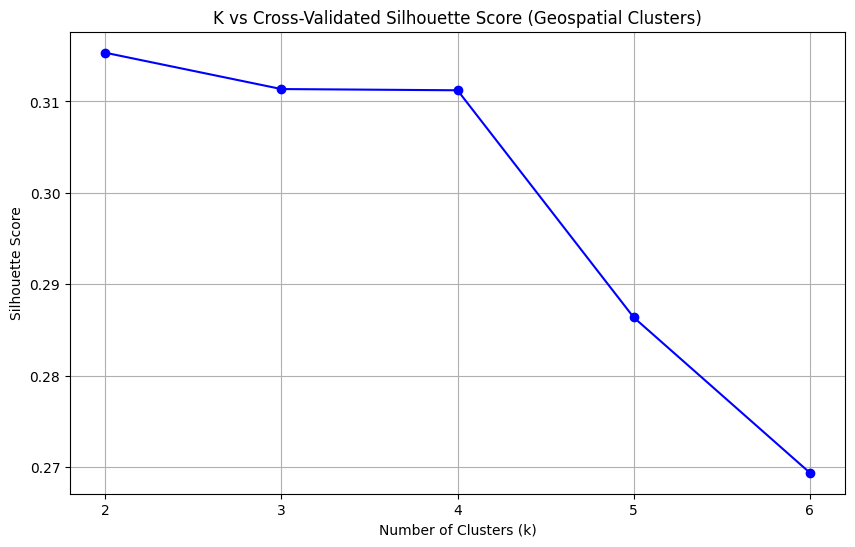

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import silhouette_score

# Systematically evaluate cluster stability using K-Fold Cross Validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

k_values = [2, 3, 4, 5, 6]
best_k = None
best_silhouette = -1
avg_silhouettes = []

print("Evaluating From-Scratch K-Means using Cross-Validation techniques...")

# Manual hyperparameter tuning for unsupervised clustering
for k in k_values:
    fold_silhouettes = []
    for train_index, val_index in kf.split(X_pca):
        X_fold_train, X_fold_val = X_pca[train_index], X_pca[val_index]
        
        # Train from-scratch model
        kmeans = KMeans_From_Scratch(n_clusters=k)
        kmeans.fit_predict(X_fold_train)
        
        # Predict on validation fold (assign to nearest trained centroid)
        distances = np.linalg.norm(X_fold_val[:, np.newaxis] - kmeans.centroids, axis=2)
        val_labels = np.argmin(distances, axis=1)
        
        # Evaluate using Silhouette Score (rigorous metric for spatial clusters)
        if len(np.unique(val_labels)) > 1:
            score = silhouette_score(X_fold_val, val_labels, sample_size=5000)
            fold_silhouettes.append(score)
    
    avg_score = np.mean(fold_silhouettes)
    avg_silhouettes.append(avg_score)
    
    if avg_score > best_silhouette:
        best_silhouette = avg_score
        best_k = k

print(f"Optimal number of spatial clusters (k): {best_k}")
print(f"Best Cross-Validated Silhouette Score: {best_silhouette:.4f}")

# Plotting the evaluation
plt.figure(figsize=(10, 6))
plt.plot(k_values, avg_silhouettes, marker='o', linestyle='-', color='blue')
plt.title('K vs Cross-Validated Silhouette Score (Geospatial Clusters)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Supervised Learning (Logistic Regression) mapped to GridSearchCV, systematically evaluating Precision, Recall, and F1-scores.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Formulate a complex supervised learning task from the spatial data
# Target: Predict if a geospatial block is a "High Value Zone" (above median house value)
y_binary = (california.target > np.median(california.target)).astype(int)

# Split data to aggressively mitigate model overfitting
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_binary, test_size=0.2, random_state=42)

print("--- Supervised Learning & Optimization Phase ---")
print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

# Define Logistic Regression (Aligns with resume) and parameter grid
log_reg = LogisticRegression(max_iter=1000, solver='saga')
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10]
}

# Set up K-Fold CV and GridSearchCV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(log_reg, param_grid, cv=cv, scoring='f1', n_jobs=-1)

print("Executing GridSearchCV with K-Fold Cross Validation...")
grid_search.fit(X_train, y_train)

# Best model parameters extracted
print("Best hyperparameters found:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Systematically evaluate precision, recall, and F1-scores
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("\n--- Test Set Evaluation (Mitigating Overfitting) ---")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_test))

--- Supervised Learning & Optimization Phase ---
Training shape: (16512, 5), Test shape: (4128, 5)
Executing GridSearchCV with K-Fold Cross Validation...
Best hyperparameters found: {'C': 10, 'penalty': 'l1'}

--- Test Set Evaluation (Mitigating Overfitting) ---
Precision: 0.7617
Recall:    0.7075
F1-Score:  0.7336

Full Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      2077
           1       0.76      0.71      0.73      2051

    accuracy                           0.74      4128
   macro avg       0.75      0.74      0.74      4128
weighted avg       0.75      0.74      0.74      4128

